In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

In [2]:
# Setup
# Solver and simulation parameters
M = 8
closure = "ExtGram"
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

In [3]:
file_gramian = [f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv" for base_tree_level in base_tree_level_vec]
data_gramian = [pd.read_csv(f) for f in file_gramian]

M_reference = 24
base_tree_level_reference = 6
file_reference = f"../out/Riemann1D/Moments/gram_solution_M{M_reference}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_reference}_polydeg{polydeg}_rho_v_p.csv"
data_reference = pd.read_csv(file_reference)

In [4]:
file_M4 = f"../out/Riemann1D/Moments/gram_solution_M{4}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_reference}_polydeg{polydeg}_rho_v_p.csv"
data_M4 = pd.read_csv(file_M4)

file_M8 = f"../out/Riemann1D/Moments/gram_solution_M{8}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_reference}_polydeg{polydeg}_rho_v_p.csv"
data_M8 = pd.read_csv(file_M8)

file_M12 = f"../out/Riemann1D/Moments/gram_solution_M{12}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_reference}_polydeg{polydeg}_rho_v_p.csv"
data_M12 = pd.read_csv(file_M12)

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/2334555867.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


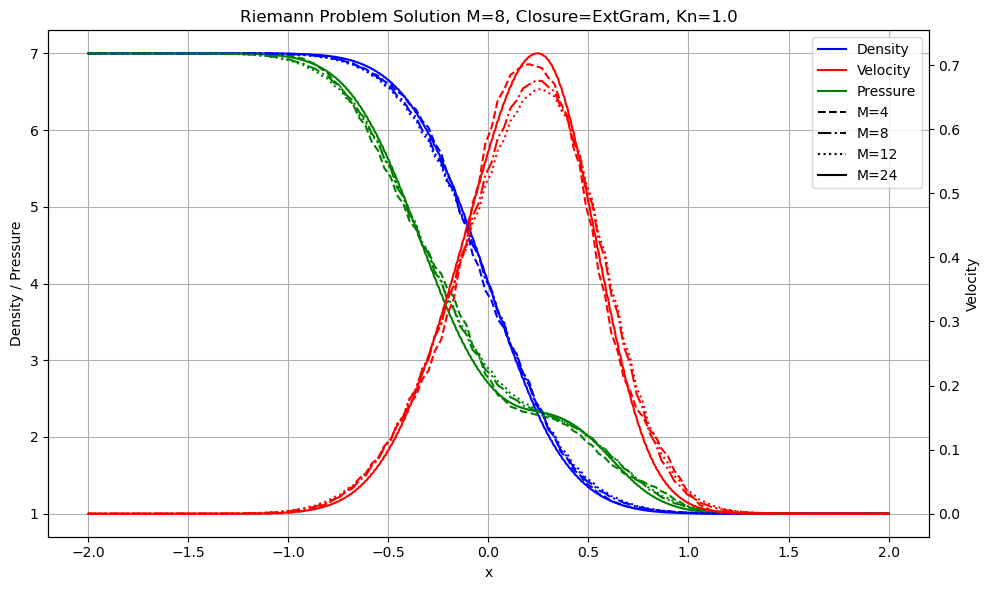

In [5]:
# Reference solution
from turtle import color


fig, axs = plt.subplots(figsize=(10, 6))
axs.plot(data_reference['x'], data_reference['rho'], color='blue')
twinx = axs.twinx()
twinx.plot(data_reference['x'], data_reference['v'], color='red')
axs.plot(data_reference['x'], data_reference['p'], color='green')

data_trixi = data_M12
axs.plot(data_M4['x'], data_M4['rho'], '--', color='blue')
twinx.plot(data_M4['x'], data_M4['v'], '--', color='red')
axs.plot(data_M4['x'], data_M4['p'], '--', color='green')

axs.plot(data_M8['x'], data_M8['rho'], '-.', color='blue')
twinx.plot(data_M8['x'], data_M8['v'], '-.', color='red')
axs.plot(data_M8['x'], data_M8['p'], '-.', color='green')

axs.plot(data_M12['x'], data_M12['rho'], ':', color='blue')
twinx.plot(data_M12['x'], data_M12['v'], ':', color='red')
axs.plot(data_M12['x'], data_M12['p'], ':', color='green')
axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
twinx.set_ylabel('Velocity')
axs.set_title(f'Riemann Problem Solution M={M}, Closure={closure}, Kn={Kn}')

axs.plot([], [], color='blue', label='Density')
axs.plot([], [], color='red', label='Velocity')
axs.plot([], [], color='green', label='Pressure')
axs.plot([], [], color='black', linestyle="--", label='M=4')
axs.plot([], [], color='black', linestyle="-.", label='M=8')
axs.plot([], [], color='black', linestyle=":", label='M=12')
axs.plot([], [], color='black', linestyle="-", label='M=24')
axs.legend(loc='upper right')
axs.grid()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/gram_solution_M_comparison.pdf')
fig.show()

In [6]:
order_x = [10**(1), 10**(3)]
offset_first_order = 0.5
first_order_y = [(1 + offset_first_order) * 10**(-1), (1 + offset_first_order) * 10**(-4/2)] 
offset_second_order = -0.5
second_order_y = [(1 + offset_second_order) * 10**(-1), (1 + offset_second_order) * 10**(-3)] 

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/1144368288.py:23: SyntaxWarning: invalid escape sequence '\m'
  axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/1144368288.py:24: SyntaxWarning: invalid escape sequence '\m'
  axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/1144368288.py:29: SyntaxWarning: invalid escape sequence '\l'
  axs.set_xlabel('$\log(N_x)$')
/v

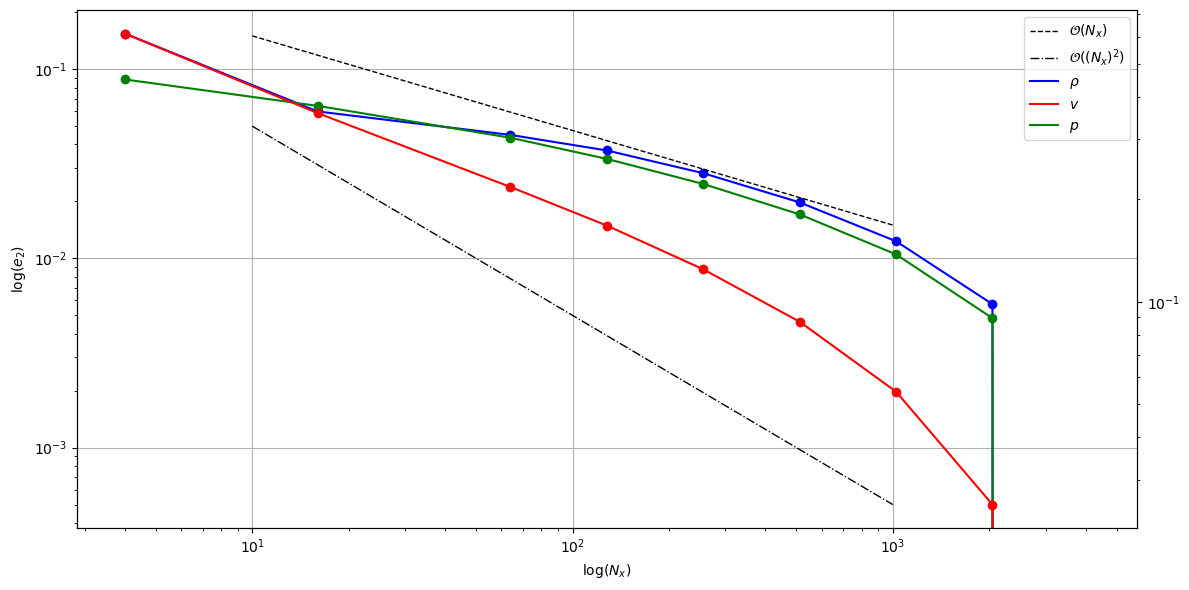

In [7]:
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12]#!, 13, 14]
M = 4
file_gramian = [f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv" for base_tree_level in base_tree_level_vec]
data_gramian = [pd.read_csv(f) for f in file_gramian]

errors = {}
Nx = []
for key in ['rho', 'v', 'p']:
    errors[key] = []
    ref_solution = interp1d(data_gramian[-1]['x'], data_gramian[-1][key])  # Using the same data as reference for simplicity
    for tree_level in base_tree_level_vec:
        data_trixi = data_gramian[base_tree_level_vec.index(tree_level)]
        error = np.linalg.norm(ref_solution(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(ref_solution(data_trixi['x']), 2)
        errors[key].append(error)
        if key == 'rho':
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

fig, axs = plt.subplots(figsize=(12,6))
axs.plot(Nx, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.loglog(Nx, errors['v'], marker='o', color='red')
axs.loglog(Nx, errors['p'], marker='o', color='green')
axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('$\log(N_x)$')
axs.set_ylabel('$\log(e_2)$')
axs.grid(True)
axs.legend()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/GridConvergence_M4.pdf')
fig.show()

In [8]:
order_x = [10**(1), 10**(3)]
offset_first_order = 0.5
first_order_y = [(1 + offset_first_order) * 10**(-1), (1 + offset_first_order) * 10**(-4/2)] 
offset_second_order = -0.5
second_order_y = [(1 + offset_second_order) * 10**(-1), (1 + offset_second_order) * 10**(-3)] 

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/1390028554.py:23: SyntaxWarning: invalid escape sequence '\m'
  axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/1390028554.py:24: SyntaxWarning: invalid escape sequence '\m'
  axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/1390028554.py:29: SyntaxWarning: invalid escape sequence '\l'
  axs.set_xlabel('$\log(N_x)$')
/v

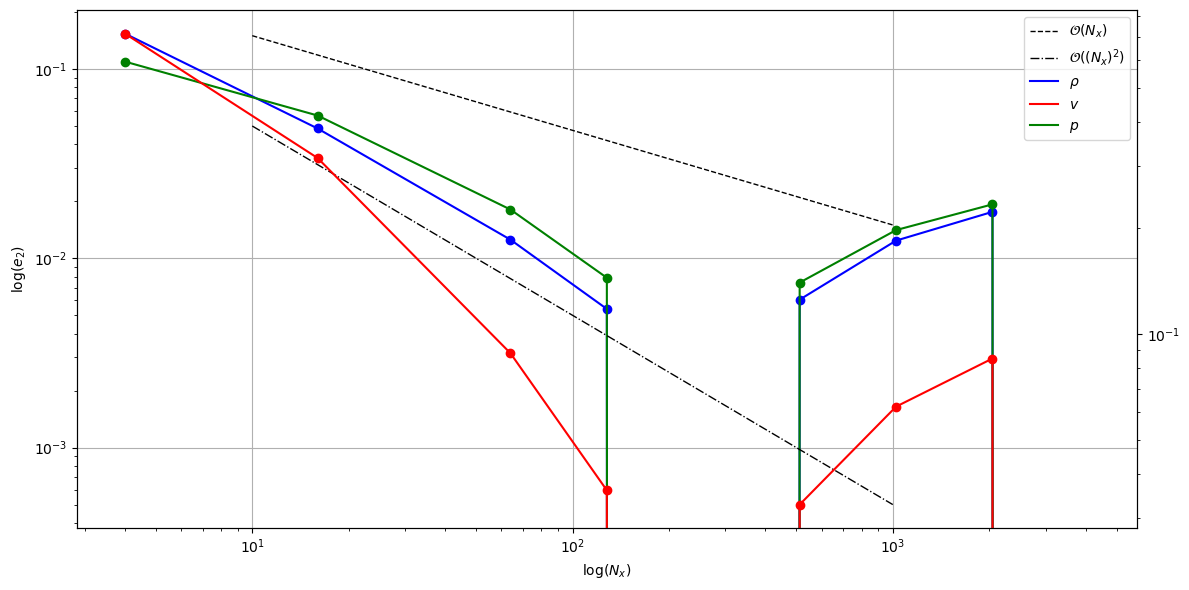

In [9]:
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12]#!, 13, 14]
M = 8
file_gramian = [f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv" for base_tree_level in base_tree_level_vec]
data_gramian = [pd.read_csv(f) for f in file_gramian]

errors = {}
Nx = []
for key in ['rho', 'v', 'p']:
    errors[key] = []
    ref_solution = interp1d(data_gramian[-1]['x'], data_gramian[-1][key])  # Using the same data as reference for simplicity
    for tree_level in base_tree_level_vec:
        data_trixi = data_gramian[base_tree_level_vec.index(tree_level)]
        error = np.linalg.norm(ref_solution(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(ref_solution(data_trixi['x']), 2)
        errors[key].append(error)
        if key == 'rho':
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

fig, axs = plt.subplots(figsize=(12,6))
axs.plot(Nx, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.loglog(Nx, errors['v'], marker='o', color='red')
axs.loglog(Nx, errors['p'], marker='o', color='green')
axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('$\log(N_x)$')
axs.set_ylabel('$\log(e_2)$')
axs.grid(True)
axs.legend()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/GridConvergence_M8.pdf')
fig.show()

In [10]:
order_x = [10**(1), 10**(3)]
offset_first_order = 0.5
first_order_y = [(1 + offset_first_order) * 10**(-1), (1 + offset_first_order) * 10**(-4/2)] 
offset_second_order = -0.5
second_order_y = [(1 + offset_second_order) * 10**(-1), (1 + offset_second_order) * 10**(-3)] 

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/3906590078.py:24: SyntaxWarning: invalid escape sequence '\m'
  axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/3906590078.py:25: SyntaxWarning: invalid escape sequence '\m'
  axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_65488/3906590078.py:30: SyntaxWarning: invalid escape sequence '\l'
  axs.set_xlabel('$\log(N_x)$')
/v

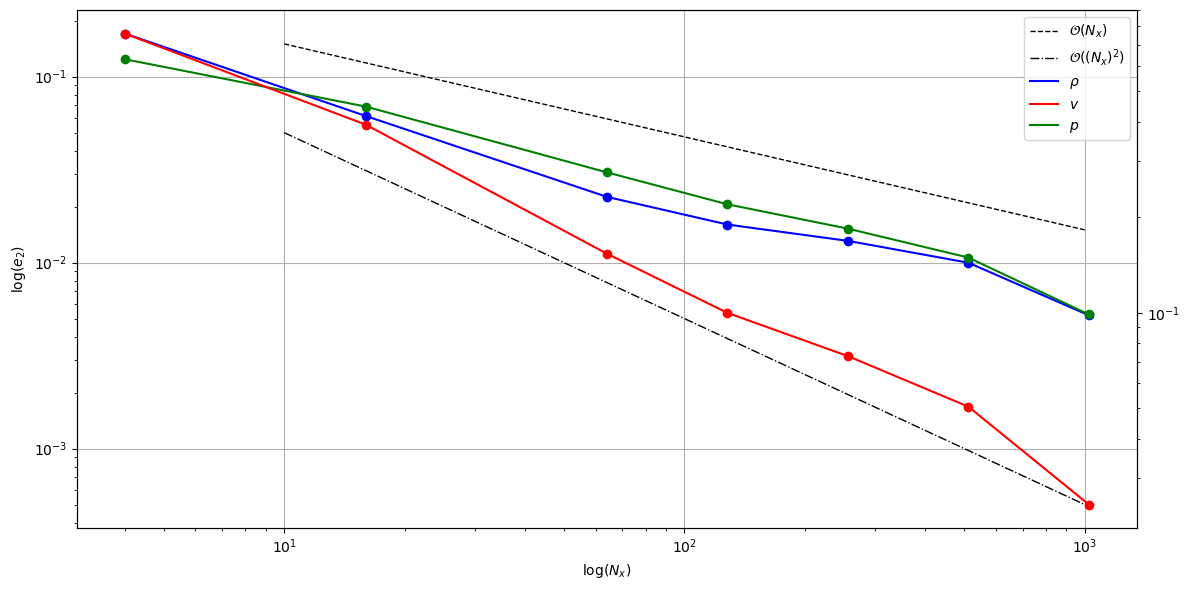

In [11]:
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11]#!, 12, 13, 14]
M = 12
file_gramian = [f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv" for base_tree_level in base_tree_level_vec]
data_gramian = [pd.read_csv(f) for f in file_gramian]


errors = {}
Nx = []
for key in ['rho', 'v', 'p']:
    errors[key] = []
    ref_solution = interp1d(data_gramian[-1]['x'], data_gramian[-1][key])  # Using the same data as reference for simplicity
    for tree_level in base_tree_level_vec[:-1]:
        data_trixi = data_gramian[base_tree_level_vec.index(tree_level)]
        error = np.linalg.norm(ref_solution(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(ref_solution(data_trixi['x']), 2)
        errors[key].append(error)
        if key == 'rho':
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

fig, axs = plt.subplots(figsize=(12,6))
axs.plot(Nx, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.loglog(Nx, errors['v'], marker='o', color='red')
axs.loglog(Nx, errors['p'], marker='o', color='green')
axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('$\log(N_x)$')
axs.set_ylabel('$\log(e_2)$')
axs.grid(True)
axs.legend()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/GridConvergence_M12.pdf')
fig.show()